In [4]:
#inputs
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pandas as pd
import seaborn as sns



In [5]:
#run prediction code -> sbatch predict.sh
#outputs should be
#chrom	mid	embedding_id	predicted_counts	target_counts
#chr22	tensor(16601530)	AG10697	82.31743432418034	11.067932097548955

In [9]:
df = pd.read_table('/home/mbrannon/output.tsv')

In [11]:
df

,chrom,mid,embedding_id,predicted_counts,target_counts
0,chr22,tensor(16601530),AG10697,82.317434,11.067932
1,chr22,tensor(16774792),AG10697,51.184257,35.067931
2,chr22,tensor(17121164),AG10697,31.998422,105.067930
3,chr22,tensor(17121463),AG10697,133.099445,246.067939
4,chr22,tensor(17159017),AG10697,101.034478,177.067939
...,...,...,...,...,...
705093,chr22,tensor(46117132),AG96530,9.123122,12.094740
705094,chr9,tensor(133429626),AG96530,10.925798,8.094740
705095,chr22,tensor(50300804),AG96530,21.072324,5.094740
705096,chr9,tensor(77020055),AG96530,50.944711,8.094740


In [12]:
# Drop rows with any NaNs in the specified columns
df = df.dropna(subset=["chrom", "mid", "embedding_id", "predicted_counts", "target_counts"])


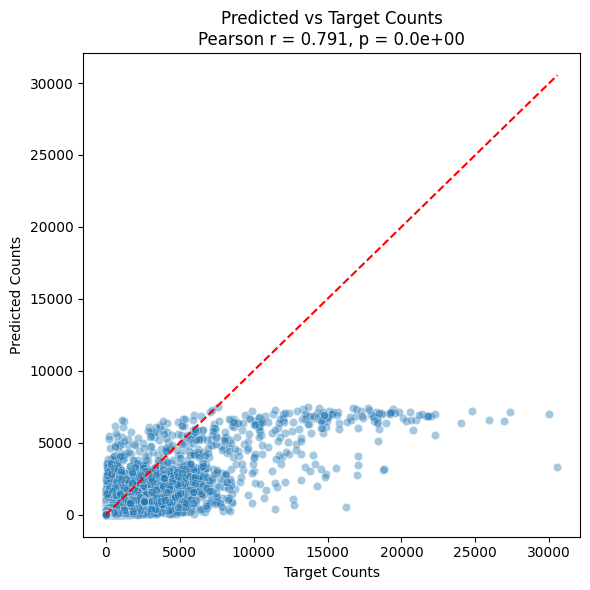

In [13]:
# Calculate overall Pearson
r, p = pearsonr(df["predicted_counts"], df["target_counts"])

# Plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x="target_counts", y="predicted_counts", data=df, alpha=0.4)
plt.title(f"Predicted vs Target Counts\nPearson r = {r:.3f}, p = {p:.1e}")
plt.xlabel("Target Counts")
plt.ylabel("Predicted Counts")
plt.plot([df["target_counts"].min(), df["target_counts"].max()],
         [df["target_counts"].min(), df["target_counts"].max()],
         'r--')
plt.tight_layout()
plt.show()


/tmp/ipykernel_27236/1721882356.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["log_predicted"] = np.log1p(df["predicted_counts"])
/tmp/ipykernel_27236/1721882356.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["log_target"] = np.log1p(df["target_counts"])


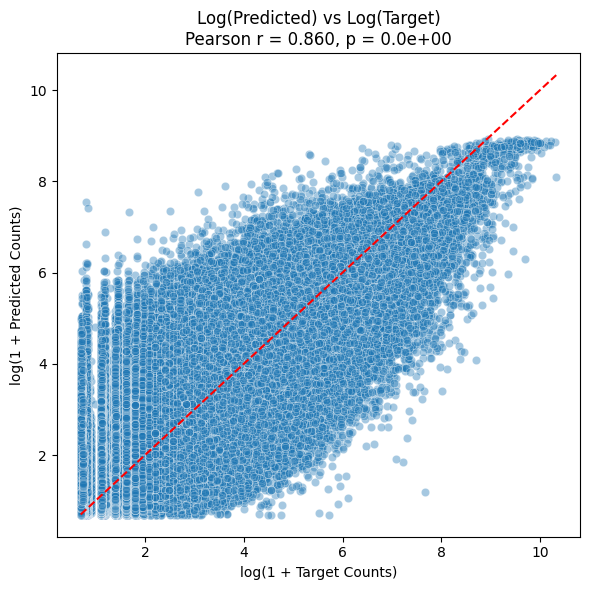

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Apply log transformation (handles 0s safely)
df["log_predicted"] = np.log1p(df["predicted_counts"])
df["log_target"] = np.log1p(df["target_counts"])

# Calculate Pearson correlation in log-space
r, p = pearsonr(df["log_predicted"], df["log_target"])

# Plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x="log_target", y="log_predicted", data=df, alpha=0.4)
plt.title(f"Log(Predicted) vs Log(Target)\nPearson r = {r:.3f}, p = {p:.1e}")
plt.xlabel("log(1 + Target Counts)")
plt.ylabel("log(1 + Predicted Counts)")
plt.plot([df["log_target"].min(), df["log_target"].max()],
         [df["log_target"].min(), df["log_target"].max()],
         'r--')
plt.tight_layout()
plt.show()


In [20]:
# Calculate Pearson correlation for each embedding_id group, and include the count of samples per group
grouped_by_sample = (
    df.groupby("embedding_id")
    .apply(lambda g: pearsonr(g["log_predicted"], g["log_target"])[0])  # Compute Pearson correlation
    .reset_index(name="pearson_r")
)

# Add a column with the count of samples per embedding_id group
grouped_by_sample['sample_count'] = df.groupby("embedding_id").size().reset_index(name="sample_count")['sample_count']

# Check the first few rows to confirm
print(grouped_by_sample.head())


  embedding_id  pearson_r  sample_count
0      AG10697   0.771220          4042
1      AG15858   0.746848          4422
2      AG58676   0.912302          1023
3      AG58686   0.905378          1154
4      AG58700   0.904877          1092


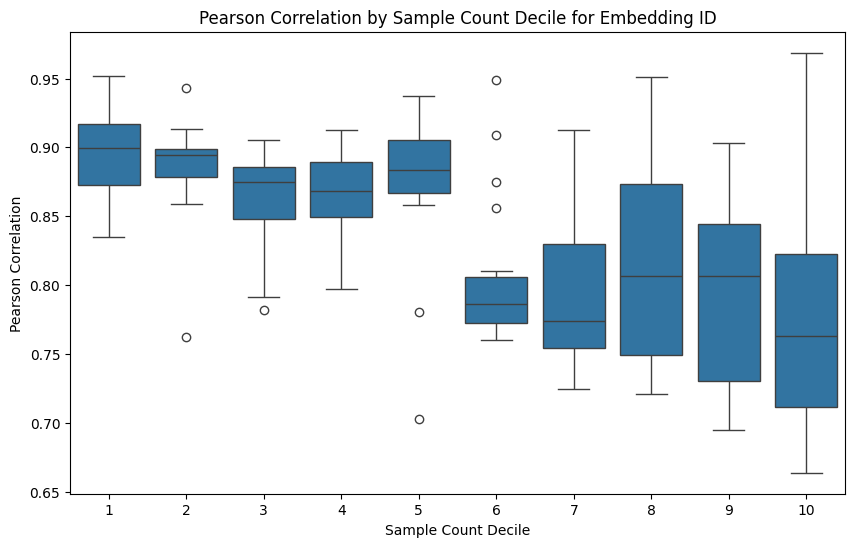

In [21]:
# Create deciles for sample count
grouped_by_sample['sample_count_decile'] = pd.qcut(grouped_by_sample['sample_count'], 10, labels=False) + 1

# Create a box plot of the Pearson correlation, grouped by sample count decile
plt.figure(figsize=(10, 6))
sns.boxplot(x="sample_count_decile", y="pearson_r", data=grouped_by_sample)
plt.title('Pearson Correlation by Sample Count Decile for Embedding ID')
plt.xlabel('Sample Count Decile')
plt.ylabel('Pearson Correlation')
plt.show()


In [25]:
deciles, bin_edges = pd.qcut(grouped_by_sample['sample_count'], 10, retbins=True, labels=False)
print("Decile bin edges:", bin_edges)


Decile bin edges: [  227.    304.9   347.6   411.4   955.8  1920.5  3309.6  4541.5  5692.2
  7702.7 33142. ]


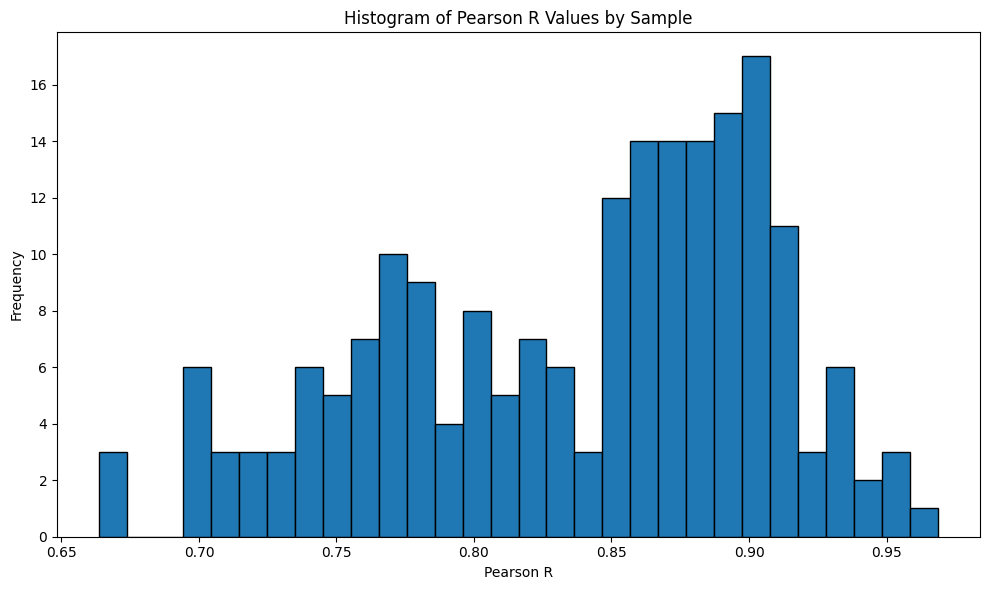

In [22]:
# Assuming 'grouped_by_sample' contains the 'pearson_r' column
plt.figure(figsize=(10, 6))

# Plotting the histogram
plt.hist(grouped_by_sample['pearson_r'], bins=30, edgecolor='black')

# Adding labels and title
plt.title("Histogram of Pearson R Values by Sample")
plt.xlabel("Pearson R")
plt.ylabel("Frequency")

# Show the plot
plt.tight_layout()
plt.show()


In [23]:
# Filter rows with pearson_r < 0.6
filtered_samples = grouped_by_sample[grouped_by_sample['pearson_r'] < 0.7]

# Display the filtered samples
print(filtered_samples)


    embedding_id  pearson_r  sample_count  sample_count_decile
95       AG80380   0.673087         27646                   10
110      AG80583   0.698736          7370                    9
112      AG80601   0.669120          8092                   10
130      AG80762   0.694788          6428                    9
132      AG80781   0.663655          8663                   10
133      AG80785   0.698431          8652                   10
135      AG80854   0.697240          6817                    9


In [3]:
import pandas as pd

# Load the file
df = pd.read_csv("/home/mbrannon/tmp/variant_pred_new_8_1.tsv", sep="\t")

# Rename the columns
df = df.rename(columns={
    "predicted_counts": "predicted_lfc",
    "target_counts": "target_lfc"
})

# (Optional) Save the updated DataFrame back to file
df.to_csv("/home/mbrannon/tmp/variant_pred_new_8_1_renamed.tsv", sep="\t", index=False)


/tmp/ipykernel_12127/1094524630.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


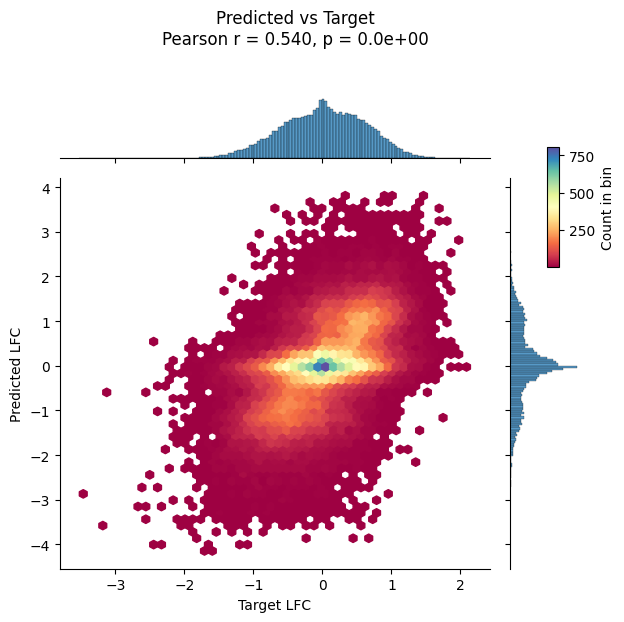

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

df = pd.read_table('/home/mbrannon/tmp/variant_pred_new_8_1.tsv')

# Pearson correlation
r, p = pearsonr(df["predicted_counts"], df["target_counts"])

# Create joint hex plot with more bins, custom color palette, and mincnt
plot = sns.jointplot(
    x="predicted_counts",
    y="target_counts",
    data=df,
    kind='hex',
    cmap="Spectral",  # Change color map for more range
    height=6,
    gridsize=50,  # More bins for finer detail
    mincnt=1  # Ensures bins with counts are shown, even if sparse
)

# Add title with Pearson r and p-value
plot.fig.suptitle(f"Predicted vs Target\nPearson r = {r:.3f}, p = {p:.1e}", y=1.03)

# Adjust axes labels
plot.set_axis_labels("Target LFC", "Predicted LFC")

# Custom colorbar position
cbar_ax = plot.fig.add_axes([.92, .6, .02, .2])  # right side
plt.colorbar(plot.ax_joint.collections[0], cax=cbar_ax, label="Count in bin")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import h5py
import os
from pathlib import Path

# Path to the input .bed.gz file
input_path = "/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v4/output/non_aggregated.extended_annotation_id.bed.gz"
output_path = "/home/mbrannon/tmp/sample_data.h5"

# Read the file while skipping comment lines
df = pd.read_csv(input_path, sep="\t")

df_small = df[[
    "#chr",
    "start",
    "ref",
    "alt",
    "ref_counts",
    "alt_counts",
    "BAD",
    "sample_id",
    "logit_es"
]].copy()

df_small.rename(columns={"start": "pos",'#chr':'chrom'}, inplace=True)
df_small["total_counts"] = df_small["ref_counts"] + df_small["alt_counts"]

df_small = df_small[[
    "chrom", "pos", "ref", "alt",
    "ref_counts", "total_counts", "BAD",
    "sample_id", "logit_es"
]]

df_small


# Make sure output dir exists
output_dir = "/home/mbrannon/tmp/eval_samples"
os.makedirs(output_dir, exist_ok=True)

df_small = df_small.sample(frac=1, random_state=42).reset_index(drop=True)
split_dfs = np.array_split(df_small, 100)


def write_chunk_to_h5(df, chunk_id, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    out_path = output_dir / f"{chunk_id}.h5"

    # Create special dtype for variable-length strings
    str_dtype = h5py.string_dtype(encoding='utf-8')
    
    assert set(
        [
            "chrom",
            "pos",
            "ref",
            "alt",
            "ref_counts",
            "total_counts",
            "BAD",
            "logit_es",
            "sample_id"
        ]
    ).issubset(df.columns)

    with h5py.File(out_path, "w") as f:
        # Create datasets directly at the root level (no group header)
        f.create_dataset("chrom", data=df["chrom"].astype(str).values, dtype=str_dtype)
        f.create_dataset("pos", data=df["pos"].astype(np.int32).values)
        f.create_dataset("ref", data=df["ref"].astype(str).values, dtype=str_dtype)
        f.create_dataset("alt", data=df["alt"].astype(str).values, dtype=str_dtype)
        f.create_dataset("ref_counts", data=df["ref_counts"].astype(np.float32).values)
        f.create_dataset("total_counts", data=df["total_counts"].astype(np.float32).values)
        f.create_dataset("BAD", data=df["BAD"].astype(np.float32).values)
        f.create_dataset("logit_es", data=df["logit_es"].astype(np.float32).values)
        f.create_dataset("sample_id", data=df["sample_id"].astype(str).values, dtype=str_dtype)

    print(f"Wrote: {out_path}")



In [ ]:
output_dir = "/home/mbrannon/tmp/eval_samples"
os.makedirs(output_dir, exist_ok=True)

# Output directory
output_dir = "/home/mbrannon/tmp/eval_samples"
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Run the function for each chunk
for i, chunk in enumerate(split_dfs):
    write_chunk_to_h5(chunk, i, output_dir)